In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
run_dir = Path("../runs") / '5codebooks_10k_epochs'

config = json.load(open(run_dir/"config.json", "r", encoding="utf-8"))
history = json.load(open(run_dir/"metrics.json", "r", encoding="utf-8"))

In [8]:
def plot_levels(history, key_train, key_val, title_prefix, y_label="%", batch_size=512, logy=False):
    train = np.asarray(history[key_train], dtype=float)  
    val = np.asarray(history[key_val], dtype=float)

    train_pct = (train / batch_size) * 100.0
    val_pct   = (val   / batch_size) * 100.0

    epochs = np.arange(1, train.shape[0] + 1)
    n_levels = train.shape[1]

    for l in range(n_levels):
        plt.figure(figsize=(10, 4))
        plt.plot(epochs, train_pct[:, l], label="train")
        plt.plot(epochs, val_pct[:, l],   label="fval")
        plt.title(f"Percentage of unique codes for batch")
        plt.xlabel("epoch")
        plt.ylabel("%")
        if logy:
            plt.yscale("log")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        
def plot_scalar(history, train_key, val_key, title, y_label, logy=False):
    y_tr = np.array(history[train_key], dtype=float)
    y_va = np.array(history[val_key], dtype=float)
    x = np.arange(1, len(y_tr) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(x, y_tr, label=f"train {train_key}")
    plt.plot(x, y_va, label=f"val {val_key}")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel(y_label)
    if logy:
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

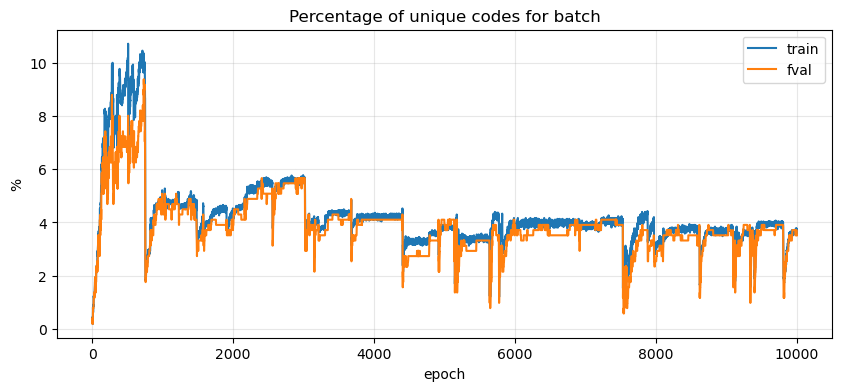

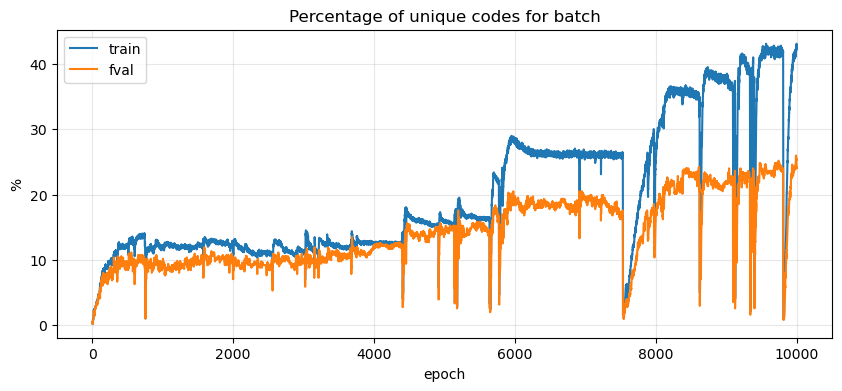

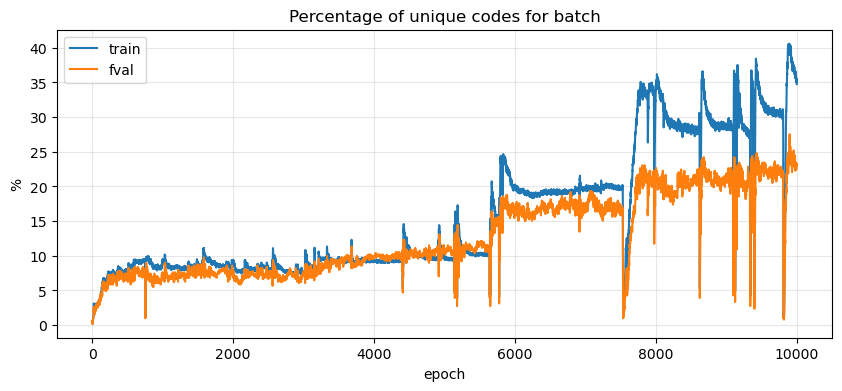

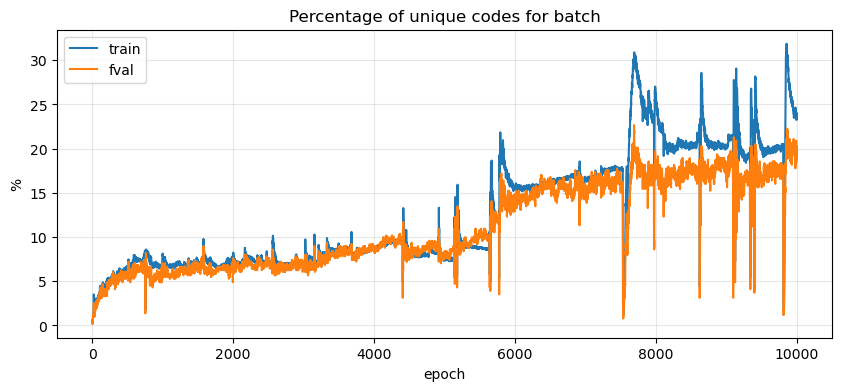

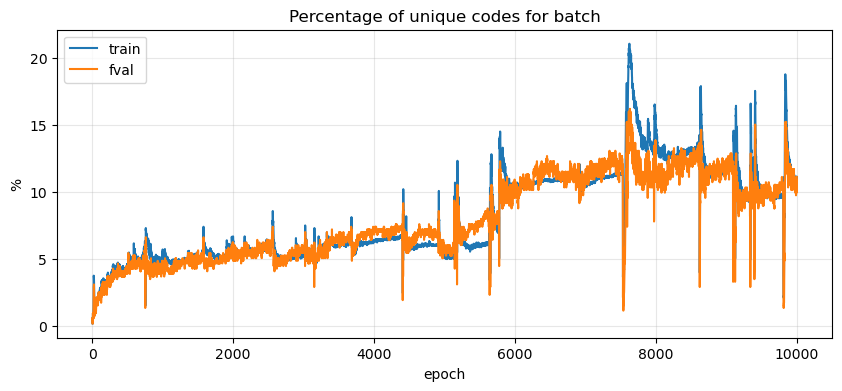

In [9]:
plot_levels(history, "train_U", "val_U", "U (unique SIDs)", "U", logy=False)

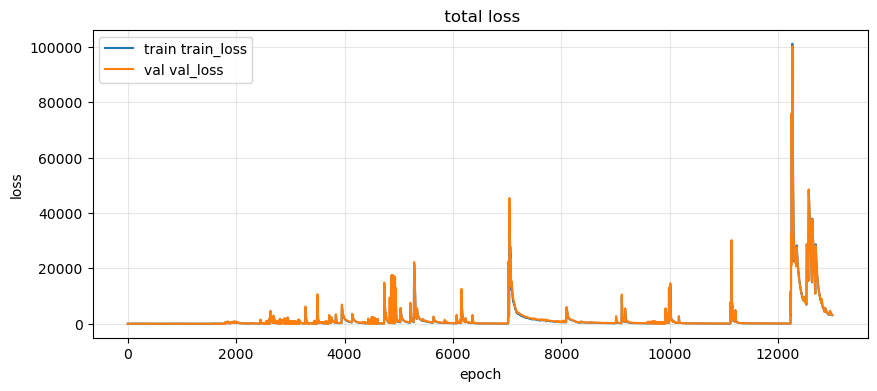

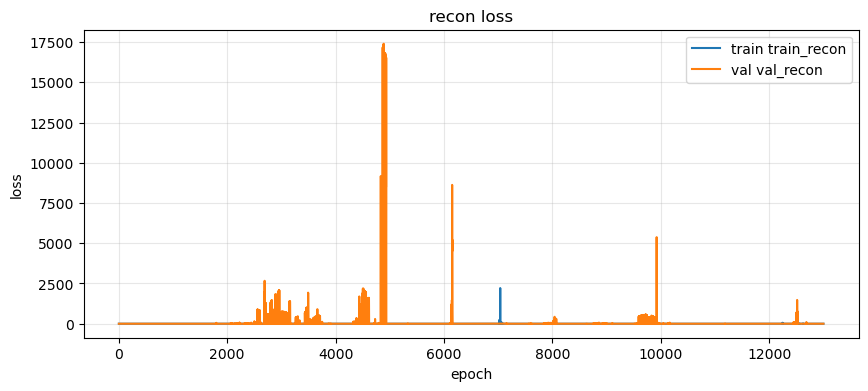

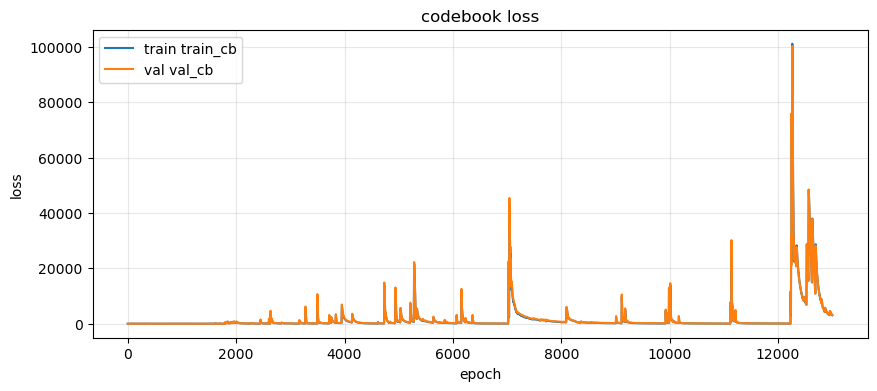

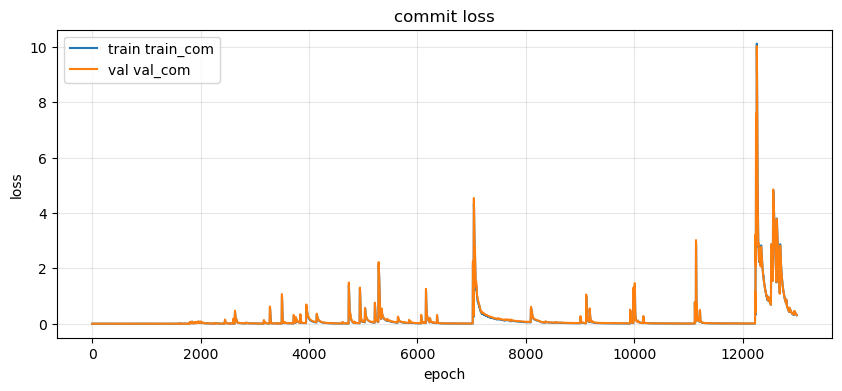

In [6]:
plot_scalar(history, "train_loss",  "val_loss",  " total loss",   "loss",  logy=False)
plot_scalar(history, "train_recon", "val_recon", "recon loss",   "loss",  logy=False)
plot_scalar(history, "train_cb",    "val_cb",    "codebook loss","loss",  logy=False)
plot_scalar(history, "train_com",   "val_com",   "commit loss",  "loss",  logy=False)